<a href="https://colab.research.google.com/github/anfalear/notasestinferencial/blob/main/ANOVA_Clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATOS ORIGINALES:
          Carretera 6  West End  Hickory St.  Ruta 59
Deans              18        17           21       22
Snaverly           16        23           23       22
Ormson             21        21           26       22
Zollaco            23        22           29       25
Filbeck            25        24           28       28


Media Global: 22.8000

Medias por Conductor:
  Deans: 19.5000
  Snaverly: 21.0000
  Ormson: 22.5000
  Zollaco: 24.7500
  Filbeck: 26.2500

Medias por Ruta:
  Carretera 6: 20.6000
  West End: 21.4000
  Hickory St.: 25.4000
  Ruta 59: 23.8000


TABLA ANOVA DE DOS VÍAS
Fuente de Variación            SC     gl           CM            F      Valor-p    F crítico
----------------------------------------------------------------------------------------------------
Conductores              119.7000      4      29.9250       9.7847     0.000934       3.2592
Rutas                     72.8000      3      24.2667       7.9346     0.003508       3.4903
Error    

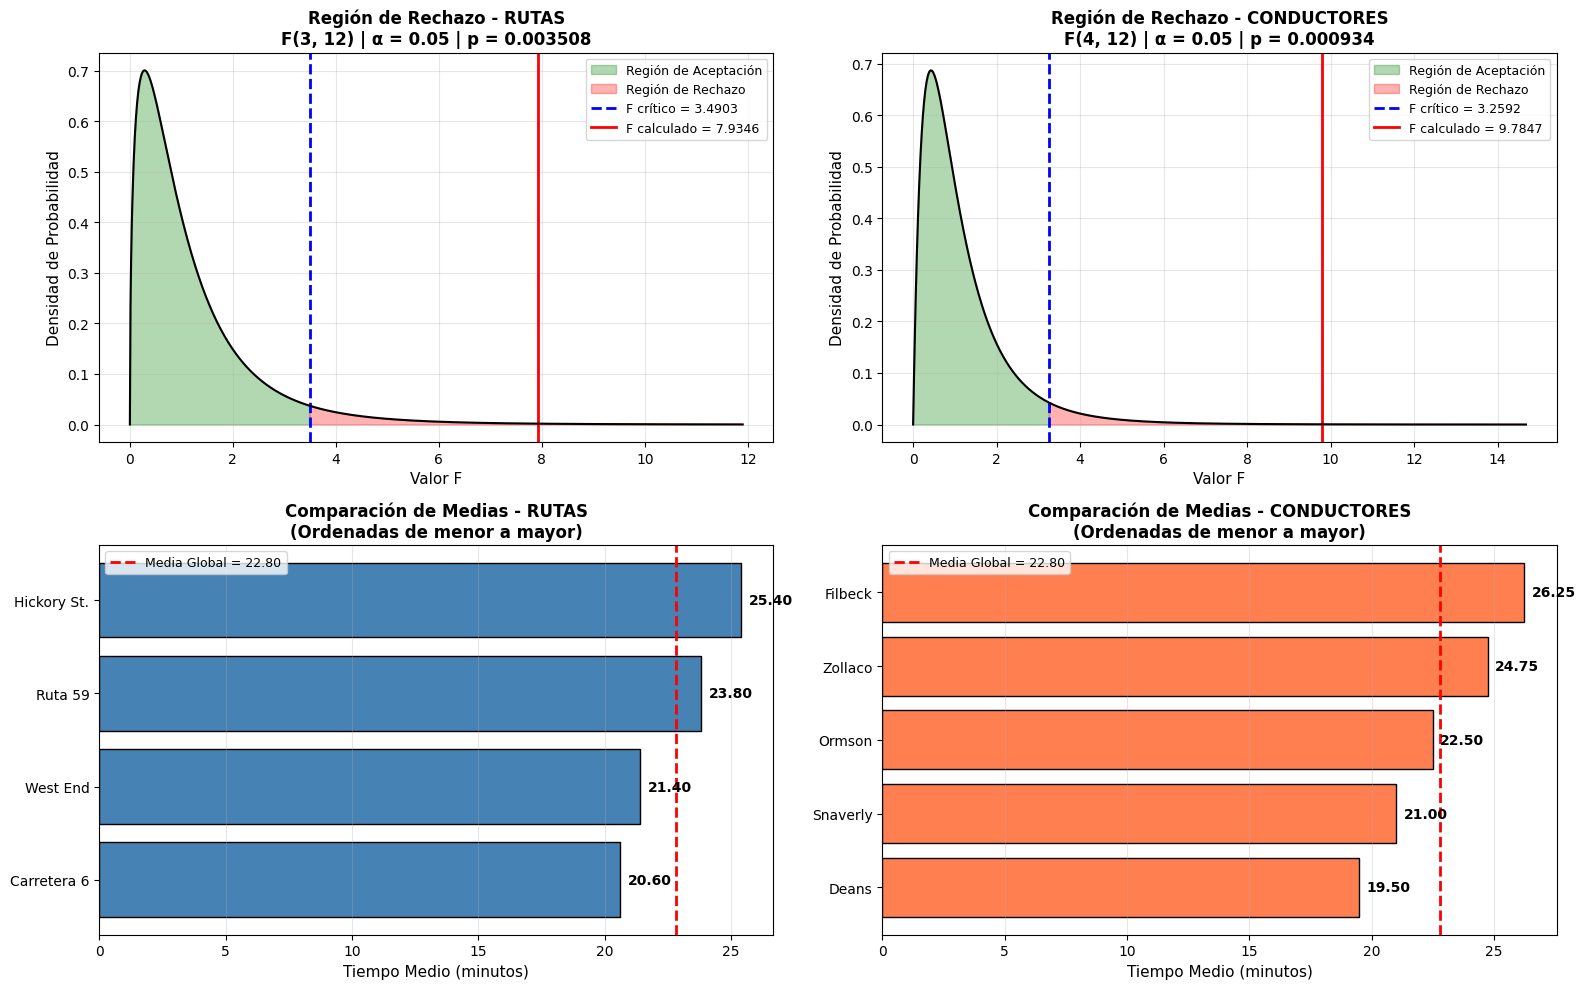

✓ Gráfico guardado como 'tukey_matrices_diferencias.png'


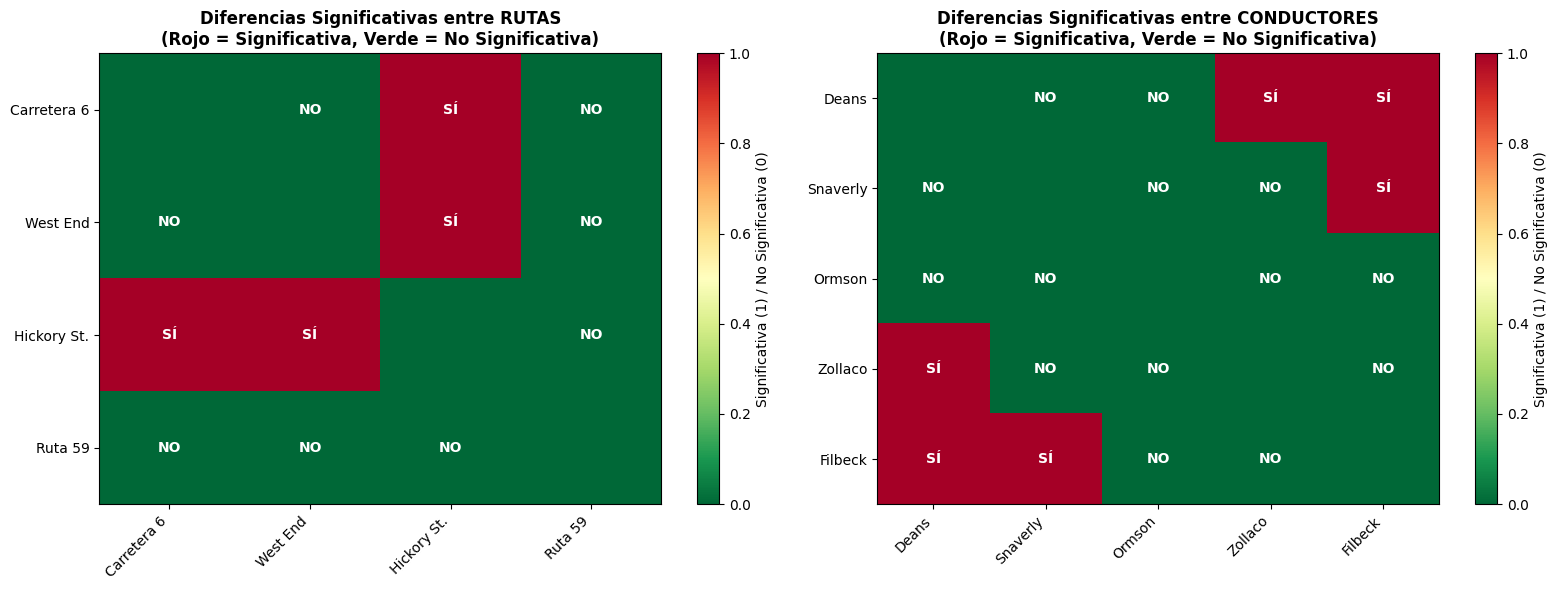


ANÁLISIS COMPLETO FINALIZADO


In [3]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from itertools import combinations

# Datos del problema
conductores = ['Deans', 'Snaverly', 'Ormson', 'Zollaco', 'Filbeck']
rutas = ['Carretera 6', 'West End', 'Hickory St.', 'Ruta 59']

# Matriz de tiempos de recorrido
datos = np.array([
    [18, 17, 21, 22],  # Deans
    [16, 23, 23, 22],  # Snaverly
    [21, 21, 26, 22],  # Ormson
    [23, 22, 29, 25],  # Zollaco
    [25, 24, 28, 28]   # Filbeck
])

# Crear DataFrame para mejor visualización
df = pd.DataFrame(datos, index=conductores, columns=rutas)
print("DATOS ORIGINALES:")
print(df)
print("\n" + "="*80 + "\n")

# Preparar datos para ANOVA
n_conductores = len(conductores)
n_rutas = len(rutas)
n_total = n_conductores * n_rutas

# Calcular medias
media_global = np.mean(datos)
medias_conductores = np.mean(datos, axis=1)
medias_rutas = np.mean(datos, axis=0)

print(f"Media Global: {media_global:.4f}")
print(f"\nMedias por Conductor:")
for i, cond in enumerate(conductores):
    print(f"  {cond}: {medias_conductores[i]:.4f}")
print(f"\nMedias por Ruta:")
for i, ruta in enumerate(rutas):
    print(f"  {ruta}: {medias_rutas[i]:.4f}")
print("\n" + "="*80 + "\n")

# ANOVA de dos vías sin interacción

# Suma de cuadrados total (SCT)
SCT = np.sum((datos - media_global)**2)

# Suma de cuadrados de conductores (SCC)
SCC = n_rutas * np.sum((medias_conductores - media_global)**2)

# Suma de cuadrados de rutas (SCR)
SCR = n_conductores * np.sum((medias_rutas - media_global)**2)

# Suma de cuadrados del error (SCE)
SCE = SCT - SCC - SCR

# Grados de libertad
gl_conductores = n_conductores - 1
gl_rutas = n_rutas - 1
gl_error = (n_conductores - 1) * (n_rutas - 1)
gl_total = n_total - 1

# Cuadrados medios
CMC = SCC / gl_conductores
CMR = SCR / gl_rutas
CME = SCE / gl_error

# Estadísticos F
F_conductores = CMC / CME
F_rutas = CMR / CME

# Valores p
p_conductores = 1 - stats.f.cdf(F_conductores, gl_conductores, gl_error)
p_rutas = 1 - stats.f.cdf(F_rutas, gl_rutas, gl_error)

# Valores críticos F para α = 0.05
F_crit_conductores = stats.f.ppf(0.95, gl_conductores, gl_error)
F_crit_rutas = stats.f.ppf(0.95, gl_rutas, gl_error)

# Crear tabla ANOVA
print("TABLA ANOVA DE DOS VÍAS")
print("="*100)
print(f"{'Fuente de Variación':<20} {'SC':>12} {'gl':>6} {'CM':>12} {'F':>12} {'Valor-p':>12} {'F crítico':>12}")
print("-"*100)
print(f"{'Conductores':<20} {SCC:>12.4f} {gl_conductores:>6} {CMC:>12.4f} {F_conductores:>12.4f} {p_conductores:>12.6f} {F_crit_conductores:>12.4f}")
print(f"{'Rutas':<20} {SCR:>12.4f} {gl_rutas:>6} {CMR:>12.4f} {F_rutas:>12.4f} {p_rutas:>12.6f} {F_crit_rutas:>12.4f}")
print(f"{'Error':<20} {SCE:>12.4f} {gl_error:>6} {CME:>12.4f}")
print(f"{'Total':<20} {SCT:>12.4f} {gl_total:>6}")
print("="*100)

# Interpretación de resultados
alpha = 0.05
print(f"\nINTERPRETACIÓN (α = {alpha}):")
print("-" * 80)

print(f"\n1. EFECTO DE CONDUCTORES:")
print(f"   F calculado = {F_conductores:.4f}")
print(f"   F crítico = {F_crit_conductores:.4f}")
print(f"   Valor-p = {p_conductores:.6f}")
if p_conductores < alpha:
    print(f"   ✓ Hay diferencia significativa entre conductores (p < {alpha})")
else:
    print(f"   ✗ No hay diferencia significativa entre conductores (p ≥ {alpha})")

print(f"\n2. EFECTO DE RUTAS:")
print(f"   F calculado = {F_rutas:.4f}")
print(f"   F crítico = {F_crit_rutas:.4f}")
print(f"   Valor-p = {p_rutas:.6f}")
if p_rutas < alpha:
    print(f"   ✓ Hay diferencia significativa entre rutas (p < {alpha})")
else:
    print(f"   ✗ No hay diferencia significativa entre rutas (p ≥ {alpha})")

print("\n" + "="*80)
print("\nRESPUESTA A LAS PREGUNTAS:")
print("-" * 80)
print("\n¿Hay diferencia entre los tiempos medios de las cuatro rutas?")
if p_rutas < alpha:
    print(f"SÍ, hay evidencia estadística significativa (p = {p_rutas:.6f} < 0.05)")
else:
    print(f"NO, no hay evidencia estadística significativa (p = {p_rutas:.6f} ≥ 0.05)")

print("\n¿Hay diferencia entre los tiempos medios de los conductores?")
print("(eliminando el efecto de las rutas)")
if p_conductores < alpha:
    print(f"SÍ, hay evidencia estadística significativa (p = {p_conductores:.6f} < 0.05)")
else:
    print(f"NO, no hay evidencia estadística significativa (p = {p_conductores:.6f} ≥ 0.05)")

# ============================================================================
# PRUEBA DE TUKEY (HSD - Honestly Significant Difference)
# ============================================================================

print("\n" + "="*80)
print("PRUEBA DE TUKEY (HSD)")
print("="*80)

# Para RUTAS
print("\n" + "-"*80)
print("COMPARACIONES MÚLTIPLES PARA RUTAS:")
print("-"*80)

# Cálculo del valor crítico de Tukey para rutas
q_rutas = stats.studentized_range.ppf(0.95, n_rutas, gl_error)
HSD_rutas = q_rutas * np.sqrt(CME / n_conductores)

print(f"\nValor crítico q (α=0.05, k={n_rutas}, gl_error={gl_error}): {q_rutas:.4f}")
print(f"HSD (Diferencia Honestamente Significativa): {HSD_rutas:.4f}")
print("\nComparaciones entre pares de rutas:")
print(f"{'Ruta i':<15} {'Ruta j':<15} {'Media i':>10} {'Media j':>10} {'Diferencia':>12} {'|Dif|':>10} {'Significativa':>15}")
print("-"*95)

comparaciones_rutas = []
for i, j in combinations(range(n_rutas), 2):
    diff = medias_rutas[i] - medias_rutas[j]
    abs_diff = abs(diff)
    es_sig = "SÍ" if abs_diff > HSD_rutas else "NO"
    comparaciones_rutas.append({
        'Ruta_i': rutas[i],
        'Ruta_j': rutas[j],
        'Media_i': medias_rutas[i],
        'Media_j': medias_rutas[j],
        'Diferencia': diff,
        'Abs_Diferencia': abs_diff,
        'Significativa': es_sig
    })
    print(f"{rutas[i]:<15} {rutas[j]:<15} {medias_rutas[i]:>10.4f} {medias_rutas[j]:>10.4f} {diff:>12.4f} {abs_diff:>10.4f} {es_sig:>15}")

# Para CONDUCTORES
print("\n" + "-"*80)
print("COMPARACIONES MÚLTIPLES PARA CONDUCTORES:")
print("-"*80)

# Cálculo del valor crítico de Tukey para conductores
q_conductores = stats.studentized_range.ppf(0.95, n_conductores, gl_error)
HSD_conductores = q_conductores * np.sqrt(CME / n_rutas)

print(f"\nValor crítico q (α=0.05, k={n_conductores}, gl_error={gl_error}): {q_conductores:.4f}")
print(f"HSD (Diferencia Honestamente Significativa): {HSD_conductores:.4f}")
print("\nComparaciones entre pares de conductores:")
print(f"{'Conductor i':<15} {'Conductor j':<15} {'Media i':>10} {'Media j':>10} {'Diferencia':>12} {'|Dif|':>10} {'Significativa':>15}")
print("-"*95)

comparaciones_conductores = []
for i, j in combinations(range(n_conductores), 2):
    diff = medias_conductores[i] - medias_conductores[j]
    abs_diff = abs(diff)
    es_sig = "SÍ" if abs_diff > HSD_conductores else "NO"
    comparaciones_conductores.append({
        'Conductor_i': conductores[i],
        'Conductor_j': conductores[j],
        'Media_i': medias_conductores[i],
        'Media_j': medias_conductores[j],
        'Diferencia': diff,
        'Abs_Diferencia': abs_diff,
        'Significativa': es_sig
    })
    print(f"{conductores[i]:<15} {conductores[j]:<15} {medias_conductores[i]:>10.4f} {medias_conductores[j]:>10.4f} {diff:>12.4f} {abs_diff:>10.4f} {es_sig:>15}")

# ============================================================================
# GRÁFICOS DE REGIÓN DE RECHAZO
# ============================================================================

print("\n" + "="*80)
print("GENERANDO GRÁFICOS...")
print("="*80)

fig = plt.figure(figsize=(16, 10))

# Gráfico 1: Región de rechazo para RUTAS
ax1 = plt.subplot(2, 2, 1)
x = np.linspace(0, max(F_rutas, F_crit_rutas) * 1.5, 1000)
y = stats.f.pdf(x, gl_rutas, gl_error)

# Área de aceptación
x_accept = x[x <= F_crit_rutas]
ax1.fill_between(x_accept, 0, stats.f.pdf(x_accept, gl_rutas, gl_error),
                  alpha=0.3, color='green', label='Región de Aceptación')

# Área de rechazo
x_reject = x[x >= F_crit_rutas]
ax1.fill_between(x_reject, 0, stats.f.pdf(x_reject, gl_rutas, gl_error),
                  alpha=0.3, color='red', label='Región de Rechazo')

# Líneas verticales
ax1.axvline(F_crit_rutas, color='blue', linestyle='--', linewidth=2, label=f'F crítico = {F_crit_rutas:.4f}')
ax1.axvline(F_rutas, color='red', linestyle='-', linewidth=2, label=f'F calculado = {F_rutas:.4f}')

ax1.plot(x, y, 'k-', linewidth=1.5)
ax1.set_xlabel('Valor F', fontsize=11)
ax1.set_ylabel('Densidad de Probabilidad', fontsize=11)
ax1.set_title(f'Región de Rechazo - RUTAS\nF({gl_rutas}, {gl_error}) | α = 0.05 | p = {p_rutas:.6f}', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Región de rechazo para CONDUCTORES
ax2 = plt.subplot(2, 2, 2)
x2 = np.linspace(0, max(F_conductores, F_crit_conductores) * 1.5, 1000)
y2 = stats.f.pdf(x2, gl_conductores, gl_error)

# Área de aceptación
x_accept2 = x2[x2 <= F_crit_conductores]
ax2.fill_between(x_accept2, 0, stats.f.pdf(x_accept2, gl_conductores, gl_error),
                  alpha=0.3, color='green', label='Región de Aceptación')

# Área de rechazo
x_reject2 = x2[x2 >= F_crit_conductores]
ax2.fill_between(x_reject2, 0, stats.f.pdf(x_reject2, gl_conductores, gl_error),
                  alpha=0.3, color='red', label='Región de Rechazo')

# Líneas verticales
ax2.axvline(F_crit_conductores, color='blue', linestyle='--', linewidth=2, label=f'F crítico = {F_crit_conductores:.4f}')
ax2.axvline(F_conductores, color='red', linestyle='-', linewidth=2, label=f'F calculado = {F_conductores:.4f}')

ax2.plot(x2, y2, 'k-', linewidth=1.5)
ax2.set_xlabel('Valor F', fontsize=11)
ax2.set_ylabel('Densidad de Probabilidad', fontsize=11)
ax2.set_title(f'Región de Rechazo - CONDUCTORES\nF({gl_conductores}, {gl_error}) | α = 0.05 | p = {p_conductores:.6f}', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Gráfico 3: Comparaciones de Tukey para RUTAS
ax3 = plt.subplot(2, 2, 3)
rutas_ordenadas = sorted(range(n_rutas), key=lambda i: medias_rutas[i])
medias_ord_rutas = [medias_rutas[i] for i in rutas_ordenadas]
nombres_ord_rutas = [rutas[i] for i in rutas_ordenadas]

bars3 = ax3.barh(nombres_ord_rutas, medias_ord_rutas, color='steelblue', edgecolor='black')
ax3.axvline(media_global, color='red', linestyle='--', linewidth=2, label=f'Media Global = {media_global:.2f}')
ax3.set_xlabel('Tiempo Medio (minutos)', fontsize=11)
ax3.set_title('Comparación de Medias - RUTAS\n(Ordenadas de menor a mayor)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='x')

# Añadir valores en las barras
for bar, val in zip(bars3, medias_ord_rutas):
    ax3.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
             va='center', fontsize=10, fontweight='bold')

# Gráfico 4: Comparaciones de Tukey para CONDUCTORES
ax4 = plt.subplot(2, 2, 4)
cond_ordenados = sorted(range(n_conductores), key=lambda i: medias_conductores[i])
medias_ord_cond = [medias_conductores[i] for i in cond_ordenados]
nombres_ord_cond = [conductores[i] for i in cond_ordenados]

bars4 = ax4.barh(nombres_ord_cond, medias_ord_cond, color='coral', edgecolor='black')
ax4.axvline(media_global, color='red', linestyle='--', linewidth=2, label=f'Media Global = {media_global:.2f}')
ax4.set_xlabel('Tiempo Medio (minutos)', fontsize=11)
ax4.set_title('Comparación de Medias - CONDUCTORES\n(Ordenadas de menor a mayor)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='x')

# Añadir valores en las barras
for bar, val in zip(bars4, medias_ord_cond):
    ax4.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('anova_dos_vias_analisis.png', dpi=300, bbox_inches='tight')
print("\n✓ Gráfico guardado como 'anova_dos_vias_analisis.png'")
plt.show()

# Gráfico adicional: Matriz de diferencias significativas
fig2, (ax5, ax6) = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de diferencias para RUTAS
diff_matrix_rutas = np.zeros((n_rutas, n_rutas))
for i in range(n_rutas):
    for j in range(n_rutas):
        if i != j:
            diff = abs(medias_rutas[i] - medias_rutas[j])
            diff_matrix_rutas[i, j] = 1 if diff > HSD_rutas else 0

im1 = ax5.imshow(diff_matrix_rutas, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax5.set_xticks(range(n_rutas))
ax5.set_yticks(range(n_rutas))
ax5.set_xticklabels(rutas, rotation=45, ha='right')
ax5.set_yticklabels(rutas)
ax5.set_title('Diferencias Significativas entre RUTAS\n(Rojo = Significativa, Verde = No Significativa)',
              fontsize=12, fontweight='bold')

for i in range(n_rutas):
    for j in range(n_rutas):
        if i != j:
            text = ax5.text(j, i, 'SÍ' if diff_matrix_rutas[i, j] == 1 else 'NO',
                          ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.colorbar(im1, ax=ax5, label='Significativa (1) / No Significativa (0)')

# Matriz de diferencias para CONDUCTORES
diff_matrix_cond = np.zeros((n_conductores, n_conductores))
for i in range(n_conductores):
    for j in range(n_conductores):
        if i != j:
            diff = abs(medias_conductores[i] - medias_conductores[j])
            diff_matrix_cond[i, j] = 1 if diff > HSD_conductores else 0

im2 = ax6.imshow(diff_matrix_cond, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax6.set_xticks(range(n_conductores))
ax6.set_yticks(range(n_conductores))
ax6.set_xticklabels(conductores, rotation=45, ha='right')
ax6.set_yticklabels(conductores)
ax6.set_title('Diferencias Significativas entre CONDUCTORES\n(Rojo = Significativa, Verde = No Significativa)',
              fontsize=12, fontweight='bold')

for i in range(n_conductores):
    for j in range(n_conductores):
        if i != j:
            text = ax6.text(j, i, 'SÍ' if diff_matrix_cond[i, j] == 1 else 'NO',
                          ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.colorbar(im2, ax=ax6, label='Significativa (1) / No Significativa (0)')

plt.tight_layout()
plt.savefig('tukey_matrices_diferencias.png', dpi=300, bbox_inches='tight')
print("✓ Gráfico guardado como 'tukey_matrices_diferencias.png'")
plt.show()

print("\n" + "="*80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("="*80)

PROBLEMA: CIRUGÍAS EN HOSPITALES DE TULSA, OKLAHOMA

DATOS ORIGINALES:
           St. Luke's  St. Vincent  Mercy
Lunes              14           18     24
Martes             20           24     14
Miércoles          16           22     14
Jueves             18           20     22
Viernes            20           28     24


Media Global: 19.8667 cirugías

Medias por Día de la Semana:
  Lunes.......  18.6667 cirugías
  Martes......  19.3333 cirugías
  Miércoles...  17.3333 cirugías
  Jueves......  20.0000 cirugías
  Viernes.....  24.0000 cirugías

Medias por Hospital:
  St. Luke's.....  17.6000 cirugías
  St. Vincent....  22.4000 cirugías
  Mercy..........  19.6000 cirugías


TABLA ANOVA DE DOS VÍAS
Fuente de Variación            SC     gl           CM            F      Valor-p    F crítico
----------------------------------------------------------------------------------------------------
Días de la Semana         75.7333      4      18.9333       1.2851     0.352359       3.8379
Hospit

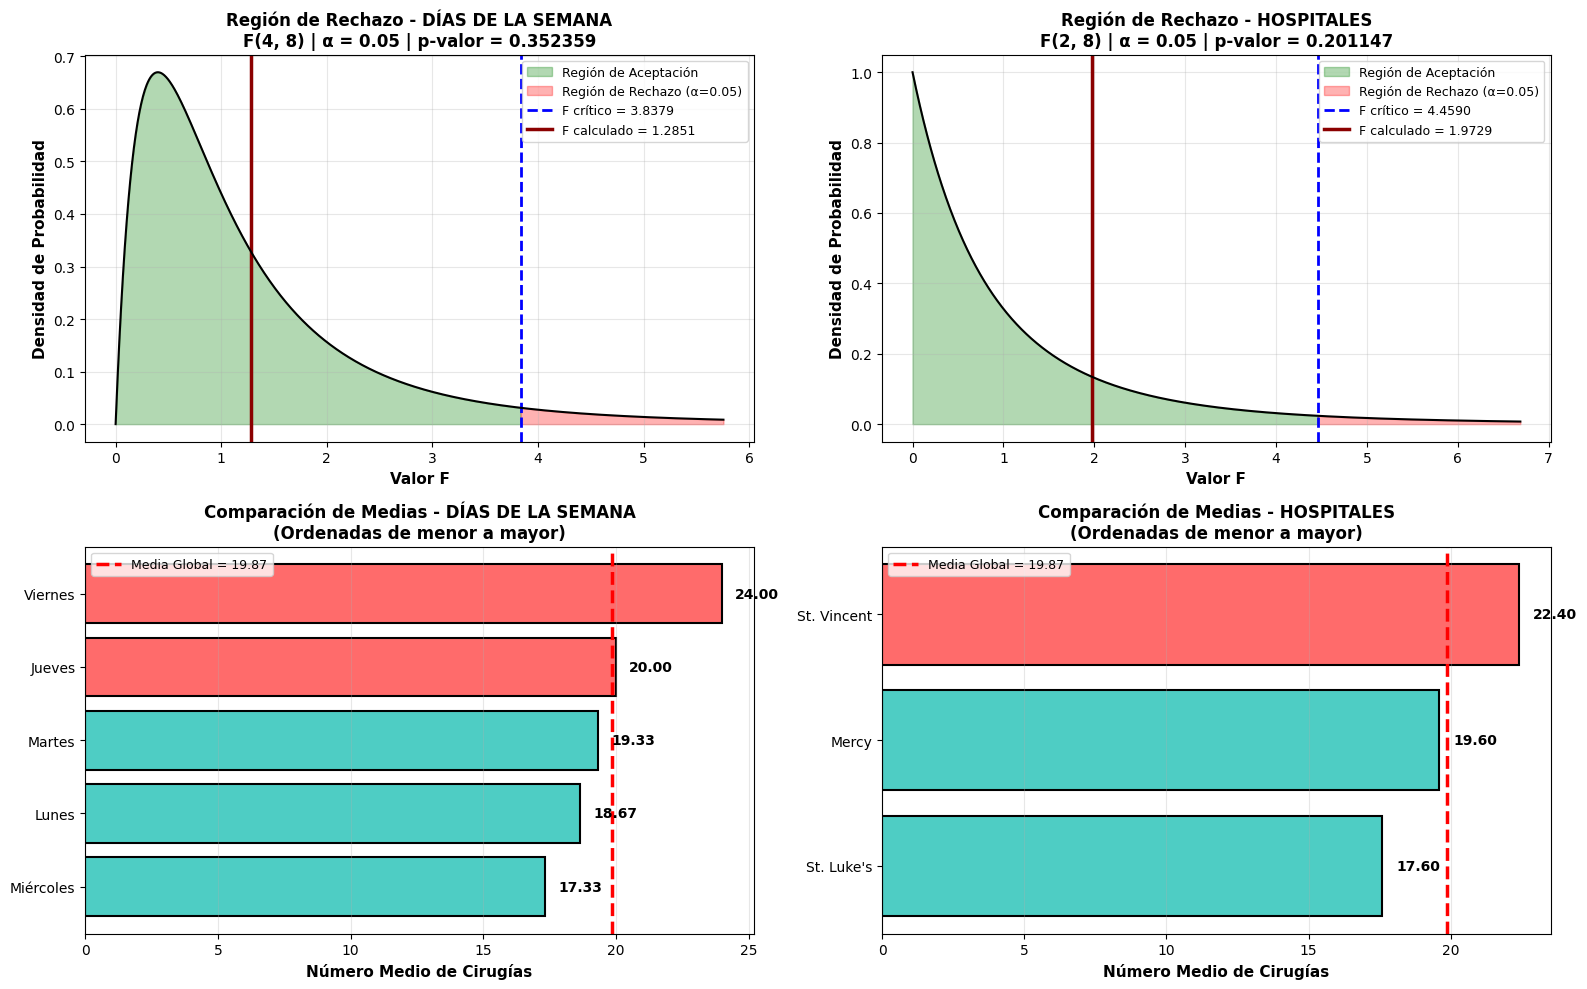

✓ Gráfico guardado como 'cirugias_tukey_matrices.png'


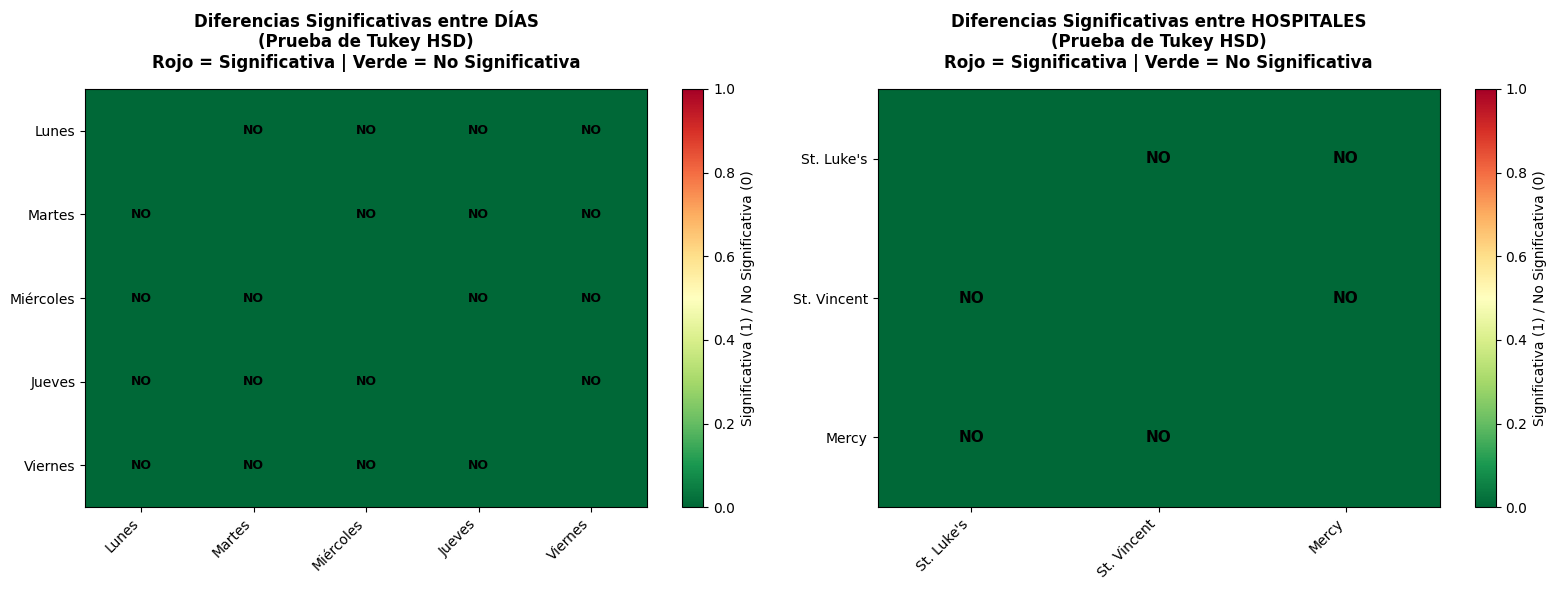


ANÁLISIS COMPLETO FINALIZADO

CONCLUSIÓN FINAL:
--------------------------------------------------------------------------------
✗ No se encontraron diferencias significativas ni por hospital ni por día.


In [4]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from itertools import combinations

# Configuración para mejor visualización
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10

# Datos del problema - Hospitales de Tulsa, Oklahoma
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes']
hospitales = ["St. Luke's", "St. Vincent", "Mercy"]

# Matriz de número de cirugías realizadas
datos = np.array([
    [14, 18, 24],  # Lunes
    [20, 24, 14],  # Martes
    [16, 22, 14],  # Miércoles
    [18, 20, 22],  # Jueves
    [20, 28, 24]   # Viernes
])

# Crear DataFrame para mejor visualización
df = pd.DataFrame(datos, index=dias, columns=hospitales)
print("="*80)
print("PROBLEMA: CIRUGÍAS EN HOSPITALES DE TULSA, OKLAHOMA")
print("="*80)
print("\nDATOS ORIGINALES:")
print(df)
print("\n" + "="*80 + "\n")

# Preparar datos para ANOVA
n_dias = len(dias)
n_hospitales = len(hospitales)
n_total = n_dias * n_hospitales

# Calcular medias
media_global = np.mean(datos)
medias_dias = np.mean(datos, axis=1)
medias_hospitales = np.mean(datos, axis=0)

print(f"Media Global: {media_global:.4f} cirugías")
print(f"\nMedias por Día de la Semana:")
for i, dia in enumerate(dias):
    print(f"  {dia:.<12} {medias_dias[i]:>8.4f} cirugías")
print(f"\nMedias por Hospital:")
for i, hosp in enumerate(hospitales):
    print(f"  {hosp:.<15} {medias_hospitales[i]:>8.4f} cirugías")
print("\n" + "="*80 + "\n")

# ANOVA de dos vías sin interacción

# Suma de cuadrados total (SCT)
SCT = np.sum((datos - media_global)**2)

# Suma de cuadrados de días (SCD)
SCD = n_hospitales * np.sum((medias_dias - media_global)**2)

# Suma de cuadrados de hospitales (SCH)
SCH = n_dias * np.sum((medias_hospitales - media_global)**2)

# Suma de cuadrados del error (SCE)
SCE = SCT - SCD - SCH

# Grados de libertad
gl_dias = n_dias - 1
gl_hospitales = n_hospitales - 1
gl_error = (n_dias - 1) * (n_hospitales - 1)
gl_total = n_total - 1

# Cuadrados medios
CMD = SCD / gl_dias
CMH = SCH / gl_hospitales
CME = SCE / gl_error

# Estadísticos F
F_dias = CMD / CME
F_hospitales = CMH / CME

# Valores p
p_dias = 1 - stats.f.cdf(F_dias, gl_dias, gl_error)
p_hospitales = 1 - stats.f.cdf(F_hospitales, gl_hospitales, gl_error)

# Valores críticos F para α = 0.05
F_crit_dias = stats.f.ppf(0.95, gl_dias, gl_error)
F_crit_hospitales = stats.f.ppf(0.95, gl_hospitales, gl_error)

# Crear tabla ANOVA
print("TABLA ANOVA DE DOS VÍAS")
print("="*100)
print(f"{'Fuente de Variación':<20} {'SC':>12} {'gl':>6} {'CM':>12} {'F':>12} {'Valor-p':>12} {'F crítico':>12}")
print("-"*100)
print(f"{'Días de la Semana':<20} {SCD:>12.4f} {gl_dias:>6} {CMD:>12.4f} {F_dias:>12.4f} {p_dias:>12.6f} {F_crit_dias:>12.4f}")
print(f"{'Hospitales':<20} {SCH:>12.4f} {gl_hospitales:>6} {CMH:>12.4f} {F_hospitales:>12.4f} {p_hospitales:>12.6f} {F_crit_hospitales:>12.4f}")
print(f"{'Error':<20} {SCE:>12.4f} {gl_error:>6} {CME:>12.4f}")
print(f"{'Total':<20} {SCT:>12.4f} {gl_total:>6}")
print("="*100)

# Interpretación de resultados
alpha = 0.05
print(f"\nINTERPRETACIÓN (α = {alpha}):")
print("-" * 80)

print(f"\n1. EFECTO DE LOS DÍAS DE LA SEMANA:")
print(f"   F calculado = {F_dias:.4f}")
print(f"   F crítico = {F_crit_dias:.4f}")
print(f"   Valor-p = {p_dias:.6f}")
if p_dias < alpha:
    print(f"   ✓ Hay diferencia significativa entre días (p < {alpha})")
    print(f"   → El número de cirugías varía significativamente según el día")
else:
    print(f"   ✗ No hay diferencia significativa entre días (p ≥ {alpha})")
    print(f"   → El número de cirugías es similar en todos los días")

print(f"\n2. EFECTO DE LOS HOSPITALES:")
print(f"   F calculado = {F_hospitales:.4f}")
print(f"   F crítico = {F_crit_hospitales:.4f}")
print(f"   Valor-p = {p_hospitales:.6f}")
if p_hospitales < alpha:
    print(f"   ✓ Hay diferencia significativa entre hospitales (p < {alpha})")
    print(f"   → Los hospitales realizan diferentes números de cirugías")
else:
    print(f"   ✗ No hay diferencia significativa entre hospitales (p ≥ {alpha})")
    print(f"   → Los hospitales realizan números similares de cirugías")

# ============================================================================
# PRUEBA DE TUKEY (HSD - Honestly Significant Difference)
# ============================================================================

print("\n" + "="*80)
print("PRUEBA DE TUKEY (HSD) - COMPARACIONES MÚLTIPLES")
print("="*80)

# Para DÍAS DE LA SEMANA
print("\n" + "-"*80)
print("COMPARACIONES ENTRE DÍAS DE LA SEMANA:")
print("-"*80)

# Cálculo del valor crítico de Tukey para días
q_dias = stats.studentized_range.ppf(0.95, n_dias, gl_error)
HSD_dias = q_dias * np.sqrt(CME / n_hospitales)

print(f"\nValor crítico q (α=0.05, k={n_dias}, gl_error={gl_error}): {q_dias:.4f}")
print(f"HSD (Diferencia Honestamente Significativa): {HSD_dias:.4f} cirugías")
print("\nComparaciones entre pares de días:")
print(f"{'Día i':<12} {'Día j':<12} {'Media i':>10} {'Media j':>10} {'Diferencia':>12} {'|Dif|':>10} {'Significativa':>15}")
print("-"*90)

comparaciones_dias = []
for i, j in combinations(range(n_dias), 2):
    diff = medias_dias[i] - medias_dias[j]
    abs_diff = abs(diff)
    es_sig = "SÍ" if abs_diff > HSD_dias else "NO"
    comparaciones_dias.append({
        'Dia_i': dias[i],
        'Dia_j': dias[j],
        'Media_i': medias_dias[i],
        'Media_j': medias_dias[j],
        'Diferencia': diff,
        'Abs_Diferencia': abs_diff,
        'Significativa': es_sig
    })
    print(f"{dias[i]:<12} {dias[j]:<12} {medias_dias[i]:>10.4f} {medias_dias[j]:>10.4f} {diff:>12.4f} {abs_diff:>10.4f} {es_sig:>15}")

# Para HOSPITALES
print("\n" + "-"*80)
print("COMPARACIONES ENTRE HOSPITALES:")
print("-"*80)

# Cálculo del valor crítico de Tukey para hospitales
q_hospitales = stats.studentized_range.ppf(0.95, n_hospitales, gl_error)
HSD_hospitales = q_hospitales * np.sqrt(CME / n_dias)

print(f"\nValor crítico q (α=0.05, k={n_hospitales}, gl_error={gl_error}): {q_hospitales:.4f}")
print(f"HSD (Diferencia Honestamente Significativa): {HSD_hospitales:.4f} cirugías")
print("\nComparaciones entre pares de hospitales:")
print(f"{'Hospital i':<15} {'Hospital j':<15} {'Media i':>10} {'Media j':>10} {'Diferencia':>12} {'|Dif|':>10} {'Significativa':>15}")
print("-"*95)

comparaciones_hospitales = []
for i, j in combinations(range(n_hospitales), 2):
    diff = medias_hospitales[i] - medias_hospitales[j]
    abs_diff = abs(diff)
    es_sig = "SÍ" if abs_diff > HSD_hospitales else "NO"
    comparaciones_hospitales.append({
        'Hospital_i': hospitales[i],
        'Hospital_j': hospitales[j],
        'Media_i': medias_hospitales[i],
        'Media_j': medias_hospitales[j],
        'Diferencia': diff,
        'Abs_Diferencia': abs_diff,
        'Significativa': es_sig
    })
    print(f"{hospitales[i]:<15} {hospitales[j]:<15} {medias_hospitales[i]:>10.4f} {medias_hospitales[j]:>10.4f} {diff:>12.4f} {abs_diff:>10.4f} {es_sig:>15}")

# ============================================================================
# RESPUESTA A LA PREGUNTA DEL PROBLEMA
# ============================================================================

print("\n" + "="*80)
print("RESPUESTA A LA PREGUNTA DEL PROBLEMA:")
print("="*80)
print("\n¿Puede concluir que hay una diferencia entre los números medios de cirugías")
print("realizadas por cada hospital o por día de la semana?")
print("-" * 80)

print("\n📊 RESULTADO PARA HOSPITALES:")
if p_hospitales < alpha:
    print(f"   SÍ, hay diferencia significativa (p = {p_hospitales:.6f} < 0.05)")
    print(f"   Los tres hospitales realizan cantidades diferentes de cirugías.")
    # Identificar diferencias significativas
    sig_hosp = [c for c in comparaciones_hospitales if c['Significativa'] == 'SÍ']
    if sig_hosp:
        print(f"\n   Diferencias significativas encontradas:")
        for comp in sig_hosp:
            print(f"   • {comp['Hospital_i']} vs {comp['Hospital_j']}: diferencia de {comp['Abs_Diferencia']:.2f} cirugías")
else:
    print(f"   NO, no hay diferencia significativa (p = {p_hospitales:.6f} ≥ 0.05)")
    print(f"   Los tres hospitales realizan cantidades similares de cirugías.")

print("\n📅 RESULTADO PARA DÍAS DE LA SEMANA:")
if p_dias < alpha:
    print(f"   SÍ, hay diferencia significativa (p = {p_dias:.6f} < 0.05)")
    print(f"   El número de cirugías varía según el día de la semana.")
    # Identificar diferencias significativas
    sig_dias = [c for c in comparaciones_dias if c['Significativa'] == 'SÍ']
    if sig_dias:
        print(f"\n   Diferencias significativas encontradas:")
        for comp in sig_dias:
            print(f"   • {comp['Dia_i']} vs {comp['Dia_j']}: diferencia de {comp['Abs_Diferencia']:.2f} cirugías")
else:
    print(f"   NO, no hay diferencia significativa (p = {p_dias:.6f} ≥ 0.05)")
    print(f"   El número de cirugías es similar en todos los días de la semana.")

# ============================================================================
# GRÁFICOS DE REGIÓN DE RECHAZO Y COMPARACIONES
# ============================================================================

print("\n" + "="*80)
print("GENERANDO GRÁFICOS...")
print("="*80)

fig = plt.figure(figsize=(16, 10))

# Gráfico 1: Región de rechazo para DÍAS
ax1 = plt.subplot(2, 2, 1)
x = np.linspace(0, max(F_dias, F_crit_dias) * 1.5, 1000)
y = stats.f.pdf(x, gl_dias, gl_error)

# Área de aceptación
x_accept = x[x <= F_crit_dias]
ax1.fill_between(x_accept, 0, stats.f.pdf(x_accept, gl_dias, gl_error),
                  alpha=0.3, color='green', label='Región de Aceptación')

# Área de rechazo
x_reject = x[x >= F_crit_dias]
ax1.fill_between(x_reject, 0, stats.f.pdf(x_reject, gl_dias, gl_error),
                  alpha=0.3, color='red', label='Región de Rechazo (α=0.05)')

# Líneas verticales
ax1.axvline(F_crit_dias, color='blue', linestyle='--', linewidth=2, label=f'F crítico = {F_crit_dias:.4f}')
ax1.axvline(F_dias, color='darkred', linestyle='-', linewidth=2.5, label=f'F calculado = {F_dias:.4f}')

ax1.plot(x, y, 'k-', linewidth=1.5)
ax1.set_xlabel('Valor F', fontsize=11, fontweight='bold')
ax1.set_ylabel('Densidad de Probabilidad', fontsize=11, fontweight='bold')
ax1.set_title(f'Región de Rechazo - DÍAS DE LA SEMANA\nF({gl_dias}, {gl_error}) | α = 0.05 | p-valor = {p_dias:.6f}',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Región de rechazo para HOSPITALES
ax2 = plt.subplot(2, 2, 2)
x2 = np.linspace(0, max(F_hospitales, F_crit_hospitales) * 1.5, 1000)
y2 = stats.f.pdf(x2, gl_hospitales, gl_error)

# Área de aceptación
x_accept2 = x2[x2 <= F_crit_hospitales]
ax2.fill_between(x_accept2, 0, stats.f.pdf(x_accept2, gl_hospitales, gl_error),
                  alpha=0.3, color='green', label='Región de Aceptación')

# Área de rechazo
x_reject2 = x2[x2 >= F_crit_hospitales]
ax2.fill_between(x_reject2, 0, stats.f.pdf(x_reject2, gl_hospitales, gl_error),
                  alpha=0.3, color='red', label='Región de Rechazo (α=0.05)')

# Líneas verticales
ax2.axvline(F_crit_hospitales, color='blue', linestyle='--', linewidth=2, label=f'F crítico = {F_crit_hospitales:.4f}')
ax2.axvline(F_hospitales, color='darkred', linestyle='-', linewidth=2.5, label=f'F calculado = {F_hospitales:.4f}')

ax2.plot(x2, y2, 'k-', linewidth=1.5)
ax2.set_xlabel('Valor F', fontsize=11, fontweight='bold')
ax2.set_ylabel('Densidad de Probabilidad', fontsize=11, fontweight='bold')
ax2.set_title(f'Región de Rechazo - HOSPITALES\nF({gl_hospitales}, {gl_error}) | α = 0.05 | p-valor = {p_hospitales:.6f}',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3)

# Gráfico 3: Comparaciones de medias para DÍAS
ax3 = plt.subplot(2, 2, 3)
dias_ordenados = sorted(range(n_dias), key=lambda i: medias_dias[i])
medias_ord_dias = [medias_dias[i] for i in dias_ordenados]
nombres_ord_dias = [dias[i] for i in dias_ordenados]

colors3 = ['#FF6B6B' if medias_ord_dias[i] > media_global else '#4ECDC4' for i in range(n_dias)]
bars3 = ax3.barh(nombres_ord_dias, medias_ord_dias, color=colors3, edgecolor='black', linewidth=1.5)
ax3.axvline(media_global, color='red', linestyle='--', linewidth=2.5, label=f'Media Global = {media_global:.2f}')
ax3.set_xlabel('Número Medio de Cirugías', fontsize=11, fontweight='bold')
ax3.set_title('Comparación de Medias - DÍAS DE LA SEMANA\n(Ordenadas de menor a mayor)',
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='x')

# Añadir valores en las barras
for bar, val in zip(bars3, medias_ord_dias):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
             va='center', fontsize=10, fontweight='bold')

# Gráfico 4: Comparaciones de medias para HOSPITALES
ax4 = plt.subplot(2, 2, 4)
hosp_ordenados = sorted(range(n_hospitales), key=lambda i: medias_hospitales[i])
medias_ord_hosp = [medias_hospitales[i] for i in hosp_ordenados]
nombres_ord_hosp = [hospitales[i] for i in hosp_ordenados]

colors4 = ['#FF6B6B' if medias_ord_hosp[i] > media_global else '#4ECDC4' for i in range(n_hospitales)]
bars4 = ax4.barh(nombres_ord_hosp, medias_ord_hosp, color=colors4, edgecolor='black', linewidth=1.5)
ax4.axvline(media_global, color='red', linestyle='--', linewidth=2.5, label=f'Media Global = {media_global:.2f}')
ax4.set_xlabel('Número Medio de Cirugías', fontsize=11, fontweight='bold')
ax4.set_title('Comparación de Medias - HOSPITALES\n(Ordenadas de menor a mayor)',
              fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='x')

# Añadir valores en las barras
for bar, val in zip(bars4, medias_ord_hosp):
    ax4.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('cirugias_hospitales_anova.png', dpi=300, bbox_inches='tight')
print("\n✓ Gráfico guardado como 'cirugias_hospitales_anova.png'")
plt.show()

# Gráfico adicional: Matrices de diferencias significativas
fig2, (ax5, ax6) = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de diferencias para DÍAS
diff_matrix_dias = np.zeros((n_dias, n_dias))
for i in range(n_dias):
    for j in range(n_dias):
        if i != j:
            diff = abs(medias_dias[i] - medias_dias[j])
            diff_matrix_dias[i, j] = 1 if diff > HSD_dias else 0

im1 = ax5.imshow(diff_matrix_dias, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax5.set_xticks(range(n_dias))
ax5.set_yticks(range(n_dias))
ax5.set_xticklabels(dias, rotation=45, ha='right', fontsize=10)
ax5.set_yticklabels(dias, fontsize=10)
ax5.set_title('Diferencias Significativas entre DÍAS\n(Prueba de Tukey HSD)\nRojo = Significativa | Verde = No Significativa',
              fontsize=12, fontweight='bold', pad=15)

for i in range(n_dias):
    for j in range(n_dias):
        if i != j:
            text_val = 'SÍ' if diff_matrix_dias[i, j] == 1 else 'NO'
            color = 'white' if diff_matrix_dias[i, j] == 1 else 'black'
            ax5.text(j, i, text_val, ha='center', va='center',
                    color=color, fontweight='bold', fontsize=9)

plt.colorbar(im1, ax=ax5, label='Significativa (1) / No Significativa (0)')

# Matriz de diferencias para HOSPITALES
diff_matrix_hosp = np.zeros((n_hospitales, n_hospitales))
for i in range(n_hospitales):
    for j in range(n_hospitales):
        if i != j:
            diff = abs(medias_hospitales[i] - medias_hospitales[j])
            diff_matrix_hosp[i, j] = 1 if diff > HSD_hospitales else 0

im2 = ax6.imshow(diff_matrix_hosp, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax6.set_xticks(range(n_hospitales))
ax6.set_yticks(range(n_hospitales))
ax6.set_xticklabels(hospitales, rotation=45, ha='right', fontsize=10)
ax6.set_yticklabels(hospitales, fontsize=10)
ax6.set_title('Diferencias Significativas entre HOSPITALES\n(Prueba de Tukey HSD)\nRojo = Significativa | Verde = No Significativa',
              fontsize=12, fontweight='bold', pad=15)

for i in range(n_hospitales):
    for j in range(n_hospitales):
        if i != j:
            text_val = 'SÍ' if diff_matrix_hosp[i, j] == 1 else 'NO'
            color = 'white' if diff_matrix_hosp[i, j] == 1 else 'black'
            ax6.text(j, i, text_val, ha='center', va='center',
                    color=color, fontweight='bold', fontsize=11)

plt.colorbar(im2, ax=ax6, label='Significativa (1) / No Significativa (0)')

plt.tight_layout()
plt.savefig('cirugias_tukey_matrices.png', dpi=300, bbox_inches='tight')
print("✓ Gráfico guardado como 'cirugias_tukey_matrices.png'")
plt.show()

print("\n" + "="*80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("="*80)
print("\nCONCLUSIÓN FINAL:")
print("-" * 80)
if p_hospitales < alpha or p_dias < alpha:
    print("✓ Se encontraron diferencias significativas en el número de cirugías.")
    if p_hospitales < alpha and p_dias < alpha:
        print("  Tanto los hospitales como los días de la semana muestran diferencias.")
    elif p_hospitales < alpha:
        print("  Las diferencias se deben a los hospitales, no a los días.")
    else:
        print("  Las diferencias se deben a los días de la semana, no a los hospitales.")
else:
    print("✗ No se encontraron diferencias significativas ni por hospital ni por día.")
print("="*80)